In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style for the plot
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# --- Copy the final values from your experiment here ---

# Ground truth values from the Monte Carlo simulation
mc_values = np.array([28.2124, 29.1479, 27.8436])

# Predicted values from the trained Centralized model
centralized_values = np.array([28.4799, 29.6563, 27.8672])

# Predicted values from the trained Decentralized model
decentralized_values = np.array([28.29483413696289, 30.047892570495605, 27.89112091064453])

# Names for the x-axis labels
state_names = ['State after 20 steps', 'State after 500 steps', 'State after 999 steps']


# --- Calculate the relative error for each model ---
# Formula: (Prediction - True) / True
relative_error_cen = (centralized_values - mc_values) / mc_values
relative_error_dec = (decentralized_values - mc_values) / mc_values

print("--- Calculated Relative Errors ---")
print(f"Centralized:   {[f'{e:.2%}' for e in relative_error_cen]}")
print(f"Decentralized: {[f'{e:.2%}' for e in relative_error_dec]}")

--- Calculated Relative Errors ---
Centralized:   ['0.95%', '1.74%', '0.08%']
Decentralized: ['0.29%', '3.09%', '0.17%']


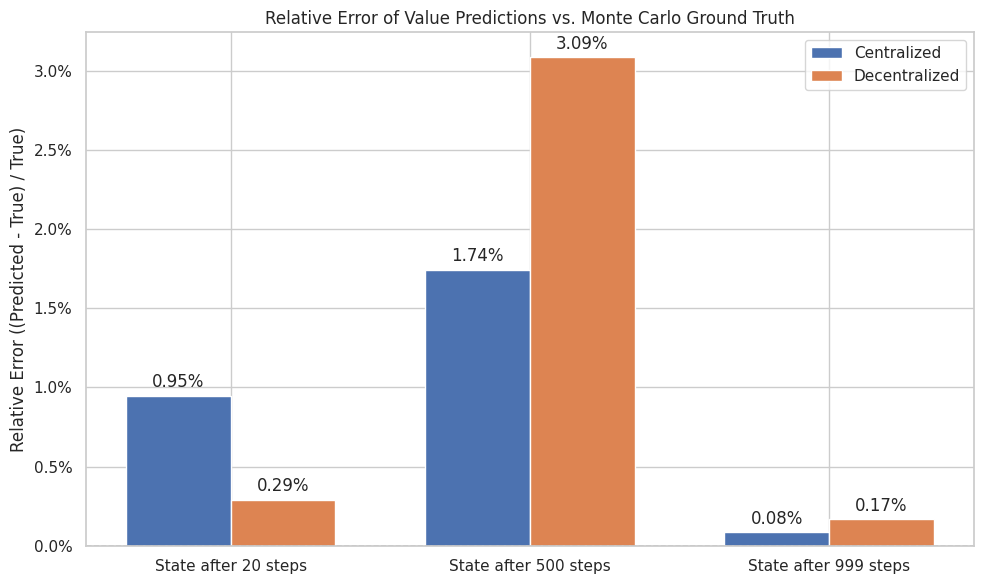

In [3]:
# --- Create the bar chart ---

x = np.arange(len(state_names))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()

# Create the bars for each model
rects1 = ax.bar(x - width/2, relative_error_cen, width, label='Centralized')
rects2 = ax.bar(x + width/2, relative_error_dec, width, label='Decentralized')

# Add a horizontal line at y=0 to represent perfect accuracy
ax.axhline(0, color='black', linestyle='--', linewidth=1)

# Add some text for labels, title and axes ticks
ax.set_ylabel('Relative Error ((Predicted - True) / True)')
ax.set_title('Relative Error of Value Predictions vs. Monte Carlo Ground Truth')
ax.set_xticks(x)
ax.set_xticklabels(state_names)  # <-- THIS IS THE CORRECTED LINE
ax.legend()

# Format the y-axis to display percentages
ax.yaxis.set_major_formatter(plt.FuncFormatter('{:.1%}'.format))

# Using your custom formatter for the bar labels
def percent_formatter(value):
    return f'{value * 100:.2f}%'

ax.bar_label(rects1, padding=3, fmt=percent_formatter)
ax.bar_label(rects2, padding=3, fmt=percent_formatter)

fig.tight_layout()
plt.show()